 ## Project 1 (Level-2) : House Price Prediction – Linear Regression
 Author: Neha Tiwari

**1. Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


**2. Load the Dataset**

In [2]:
df = pd.read_csv('Housing.csv')
df.head()


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


**3. Data Exploration**

In [6]:
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

 **4. Data Cleaning**

In [7]:
# Drop rows or fill missing values
df.dropna(inplace=True)



**6. Define Features and Encode**

In [25]:
# Clean and encode dataset for Linear Regression
# Step 1: Replace 'yes'/'no' with 1/0
df.replace({'yes': 1, 'no': 0}, inplace=True)

# Step 2: One-hot encode remaining categorical columns like 'furnishingstatus'
df = pd.get_dummies(df, drop_first=True)

# Step 3: Optional - Convert all data to integers (if needed)
df = df.astype(int)

# Step 4: Split features and target
X = df.drop("price", axis=1)
y = df["price"]


**7. Train-Test Split**

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


**8. Train the Linear Regression Model**

In [11]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

**9. Make Predictions**

In [12]:
y_pred = model.predict(X_test)


**10.  Evaluate the Model**

In [19]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")


Mean Squared Error: 1754318687330.66
R-squared: 0.65


**11. Visualize Actual vs Predicted Prices**

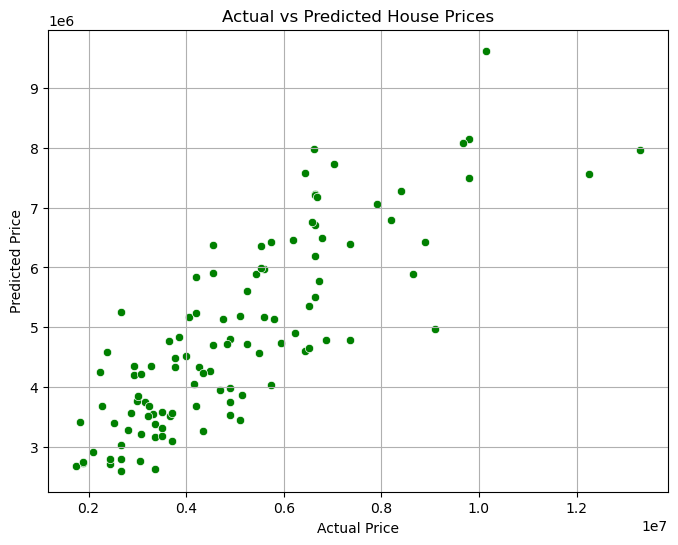

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred, color='green')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.grid(True)
plt.show()


# 🏡 House Price Prediction Using Linear Regression

## 📌 Project Overview
This project aims to build a **linear regression model** to predict house prices based on several features such as area, number of bedrooms, bathrooms, and amenities. The goal is to understand the relationship between these features and the price, and to predict the price of unseen data points accurately.

---

## 📊 Dataset Overview

- **Total Records:** 545
- **Target Variable:** `price`
- **Feature Types:**
  - Numerical: `area`, `bedrooms`, `bathrooms`, `stories`, `parking`
  - Categorical (encoded): `mainroad`, `guestroom`, `basement`, `hotwaterheating`, `airconditioning`, `prefarea`, `furnishingstatus`

All categorical features were encoded using **One-Hot Encoding** (e.g., `mainroad_yes`, `furnishingstatus_unfurnished`, etc.).

---

## 🧼 Preprocessing Steps

- Verified there were **no missing values**
- Converted boolean categories to numeric using `pd.get_dummies()`
- Converted `True/False` to `1/0` for model compatibility

---

## 🧠 Model Building

- **Algorithm Used:** Linear Regression (from Scikit-Learn)
- **Train-Test Split:** 80% training, 20% testing
- **Model Training:** Fit on training data
- **Prediction:** Made on unseen test data

---

## 📈 Model Evaluation

- **Mean Squared Error (MSE):** `1,754,318,687,330.66`
- **Root Mean Squared Error (RMSE):** `1,324,596.33` *(approximate based on MSE)*
- **R-squared (R²):** `0.65`

✅ **Interpretation**: The model explains **65% of the variance** in house prices. This is a good starting point for a linear regression model with basic features and no regularization.

---

## 📊 Visualization

A scatter plot was used to visualize **Actual vs Predicted Prices**.

```python
sns.scatterplot(x=y_test, y=y_pred)
